# Cyclistic Bike-Share: Q1 2026 Data Merger, Cleaning & Visualization
This notebook guides you step-by-step through the process of combining, cleaning, and visualizing monthly/quarterly CSV files from the `cyclistic_2026_q1_data` folder into a single, clean dataset, followed by detailed exploratory analysis.

### Steps in this Notebook:
1. **Pre-requisite Check:** Checks and installs `pandas`, `matplotlib`, and `seaborn` as needed.
2. **Step 1: Inspect Files:** Finds the CSV files in the folder and verifies that their columns and data types match.
3. **Step 2: Merge & Convert Datetime:** Loads each CSV file, converts datetime columns to a proper datetime format, and combines them (skips if already merged).
4. **Step 3: Save Merged Dataset:** Saves the merged dataset to a new file and checks the output to confirm success (skips if already merged).
5. **Step 4: Pre-Cleaning Audit:** Audits the combined dataset to find duplicates, missing values, coordinate ranges, and invalid trip durations.
6. **Step 5: Clean and Process Data:** Drops duplicates, standardizes spelling/spaces, filters out invalid trip durations and test stations, and labels missing station values.
7. **Step 6: Post-Cleaning Validation:** Verifies the final cleaned dataset to ensure integrity.
8. **Step 7: Calculate Ride Length by Day of week**: Create new columns calculating values for ride length and day of week.
9. **Step 8: Sort the dataset**: Sort by trip duration to find the longest and shortest trips.
10. **Step 9: Descriptive Analytics & Visualizations**: Analyze the data to draw insights, find relationships, and plot descriptive charts.
11. **Step 10: Advanced Analytical Insights**: Deeper dive into bike preferences, hourly rush hour patterns, round-trip rates, distance/speed, and top routes with detailed charts.

## Environment Setup
First, we make sure that the required library (`pandas`) is installed in your Jupyter environment. If it's missing, the cell below will install it automatically.

In [1]:
import sys

def install_and_import(package):
    try:
        __import__(package)
        print(f"{package} is already installed and ready to use!")
    except ImportError:
        print(f"{package} is not installed. Installing it now via pip...")
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"{package} has been successfully installed!")

install_and_import("pandas")
install_and_import("matplotlib")
install_and_import("seaborn")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100


pandas is already installed and ready to use!
matplotlib is already installed and ready to use!
seaborn is already installed and ready to use!


## Step 1: Locate and Inspect the Data Files
Before combining files, we must find them and check their structure (schema) to make sure they have the exact same columns. Merging files with different columns can lead to misaligned data or empty columns.

In [2]:
import os
import glob

# Define path to the data folder
data_dir = "cyclistic_2026_q1_data"

# Find all CSV files in the folder
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))

print(f"Found {len(csv_files)} CSV files in '{data_dir}':")
for file in csv_files:
    print(f" - {os.path.basename(file)}")

print("\nChecking schema consistency...")

# Read the headers of each file to verify they are identical
schemas = {}
for file in csv_files:
    df_temp = pd.read_csv(file, nrows=2)
    filename = os.path.basename(file)
    schemas[filename] = list(df_temp.columns)
    print(f"\nColumns in {filename}:\n  {schemas[filename]}")

# Confirm they match
first_file = list(schemas.keys())[0]
all_match = all(schemas[f] == schemas[first_file] for f in schemas)
if all_match:
    print("\nSuccess: All files have matching column names and orders!")
else:
    print("\nWarning: Columns do not match exactly! Check names or ordering.")

Found 4 CSV files in 'cyclistic_2026_q1_data':
 - 2026_01-divvy-tripdata.csv
 - 2026_02-divvy-tripdata.csv
 - 2026_03-divvy-tripdata.csv
 - 2026_04-divvy-tripdata.csv

Checking schema consistency...

Columns in 2026_01-divvy-tripdata.csv:
  ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']

Columns in 2026_02-divvy-tripdata.csv:
  ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']

Columns in 2026_03-divvy-tripdata.csv:
  ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']

Columns in 2026_04-divvy-tripdata.csv:
  ['ride_id', 'rideable_type', 'sta

## Step 2: Read, Convert Datetime, and Merge
CSV files store date and time values as plain text (strings). For time-series analysis (e.g., calculating trip duration or categorizing rides by day of the week), we need to cast these to Pandas `datetime64` objects.

**Smart Check:** If `cyclistic_2026_q1_merged.csv` already exists on disk, we will skip the merge process to save execution time and prevent redundant reads.

In [3]:
output_path = "cyclistic_2026_q1_merged.csv"
skip_merge = False

# Check if the merged file already exists
if os.path.exists(output_path):
    print(f"Merged file '{output_path}' already exists!")
    print("Loading the existing file directly to save time...")
    merged_df = pd.read_csv(output_path)
    
    # Standardize datetime types for the loaded file
    merged_df['started_at'] = pd.to_datetime(merged_df['started_at'])
    merged_df['ended_at'] = pd.to_datetime(merged_df['ended_at'])
    
    print(f"Loaded {merged_df.shape[0]:,} rows successfully.")
    skip_merge = True
else:
    all_dataframes = []
    print("Starting the merge process...")

    for file in csv_files:
        filename = os.path.basename(file)
        print(f"\nReading {filename}...")
        
        # Load CSV
        df = pd.read_csv(file)
        print(f"  - Loaded {df.shape[0]:,} rows.")
        
        # Convert datetime columns to proper datetime format
        datetime_cols = ['started_at', 'ended_at']
        for col in datetime_cols:
            if col in df.columns:
                print(f"  - Converting '{col}' to datetime format...")
                df[col] = pd.to_datetime(df[col])
                
        all_dataframes.append(df)

    # Concatenate all datasets into a single DataFrame
    print("\nCombining all DataFrames...")
    merged_df = pd.concat(all_dataframes, ignore_index=True)

    print("\nMerge Completed!")
    print(f"Total rows in merged dataset: {merged_df.shape[0]:,}")
    print(f"Total columns: {merged_df.shape[1]}")

Merged file 'cyclistic_2026_q1_merged.csv' already exists!
Loading the existing file directly to save time...


Loaded 1,104,526 rows successfully.


## Step 3: Export to CSV and Verify
If we performed a new merge, we save the combined dataset back as a single CSV file: `cyclistic_2026_q1_merged.csv`.

In [4]:
if skip_merge:
    print("Skipping export because the merged file was loaded from disk.")
else:
    print(f"Saving merged dataset to '{output_path}'...")
    print("Note: This might take a moment due to the large dataset size...")

    # Save to CSV without the row index numbers
    merged_df.to_csv(output_path, index=False)
    print("File saved successfully!")

print("\n--- Verification ---")
print(f"Merged Dataset columns: {list(merged_df.columns)}")
print(f"File shape: {merged_df.shape[0]:,} rows x {merged_df.shape[1]} columns")

# Display first 5 rows
merged_df.head(5)

Skipping export because the merged file was loaded from disk.

--- Verification ---
Merged Dataset columns: ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']
File shape: 1,104,526 rows x 13 columns


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member


## Step 4: Pre-Cleaning Audit
Before making any modifications, we perform a data audit to quantify specific problems in our merged dataset:
1. **Duplicates:** Find rows with identical `ride_id` values (each ride should be unique).
2. **Missing values:** Find missing entries across all columns.
3. **Date logic:** Check for negative trip durations (`ended_at` before `started_at`) or extremely short (< 1 min) or long (> 24 hours) trips.
4. **Test data:** Check for test or maintenance stations (e.g., station names containing "test", "temp", "maintenance", "hq", "base").
5. **Categorical spelling:** Check unique values of categorical fields (`rideable_type` and `member_casual`) for spelling/format discrepancies.

In [5]:
import pandas as pd
import numpy as np

file_path = "cyclistic_2026_q1_merged.csv"
print(f"Loading '{file_path}' for audit...")
df = pd.read_csv(file_path)

print(f"\n--- Dataset Overview ---")
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")

# 1. Check for duplicates in ride_id
duplicates_count = df.duplicated(subset=['ride_id']).sum()
print(f"\n1. Duplicate 'ride_id' count: {duplicates_count:,}")

# 2. Check for missing values in each column
print(f"\n2. Missing values per column:")
missing_counts = df.isnull().sum()
for col in df.columns:
    print(f"   - {col}: {missing_counts[col]:,} missing ({missing_counts[col]/len(df)*100:.2f}%)")

# 3. Check datetime logic (ended_at should be after started_at)
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])
df['duration_seconds'] = (df['ended_at'] - df['started_at']).dt.total_seconds()

negative_durations = (df['duration_seconds'] < 0).sum()
zero_durations = (df['duration_seconds'] == 0).sum()
short_durations = ((df['duration_seconds'] > 0) & (df['duration_seconds'] < 60)).sum()
long_durations = (df['duration_seconds'] > 86400).sum() # > 24 hours

print(f"\n3. Datetime anomalies:")
print(f"   - Trips with negative duration (ended < started): {negative_durations:,}")
print(f"   - Trips with zero duration: {zero_durations:,}")
print(f"   - Trips under 1 minute: {short_durations:,}")
print(f"   - Trips over 24 hours: {long_durations:,}")

# 4. Check for test/maintenance station names
test_stations_start = df[df['start_station_name'].str.contains('test|temp|maintenance|hq|base', case=False, na=False)]['start_station_name'].unique()
test_stations_end = df[df['end_station_name'].str.contains('test|temp|maintenance|hq|base', case=False, na=False)]['end_station_name'].unique()
all_test_stations = set(list(test_stations_start) + list(test_stations_end))
print(f"\n4. Potential test/maintenance stations found: {len(all_test_stations)}")
if len(all_test_stations) > 0:
    print("   Samples:")
    for station in list(all_test_stations)[:5]:
        print(f"   - {station}")

# 5. Check categorical values
print(f"\n5. Unique values check:")
print("   - 'rideable_type':", df['rideable_type'].unique())
print("   - 'member_casual':", df['member_casual'].unique())

Loading 'cyclistic_2026_q1_merged.csv' for audit...



--- Dataset Overview ---
Total Rows: 1,104,526
Total Columns: 13

1. Duplicate 'ride_id' count: 0

2. Missing values per column:
   - ride_id: 0 missing (0.00%)
   - rideable_type: 0 missing (0.00%)
   - started_at: 0 missing (0.00%)
   - ended_at: 0 missing (0.00%)
   - start_station_name: 206,385 missing (18.69%)
   - start_station_id: 206,385 missing (18.69%)
   - end_station_name: 219,499 missing (19.87%)
   - end_station_id: 219,499 missing (19.87%)
   - start_lat: 0 missing (0.00%)
   - start_lng: 0 missing (0.00%)
   - end_lat: 970 missing (0.09%)
   - end_lng: 970 missing (0.09%)
   - member_casual: 0 missing (0.00%)

3. Datetime anomalies:
   - Trips with negative duration (ended < started): 0
   - Trips with zero duration: 0
   - Trips under 1 minute: 28,574
   - Trips over 24 hours: 928

4. Potential test/maintenance stations found: 2
   Samples:
   - Wood St & Taylor St (Temp)
   - Kildare Ave & 85th St (Kostner Ave & 87th St TEMPORARY)

5. Unique values check:
   - 'ridea

## Step 5: Clean and Process the Dataset
Now, we execute the actual data cleaning process based on our findings. We will:
1. **Drop duplicate rows** based on `ride_id` to ensure unique entries.
2. **Trim whitespace** and convert all key categories to lowercase to ensure consistency.
3. **Filter out test/maintenance stations** (any name containing 'test', 'temp', 'maintenance', 'hq', 'base').
4. **Filter by Trip Duration:** Remove negative durations, durations of 0 seconds, trips under 1 minute (starts by mistake), and trips over 24 hours.
5. **Drop missing coordinates:** Strip rows missing latitude or longitude values, as they cannot be used for spatial analysis.
6. **Label missing station names:** Impute `"On-Street (Dockless)"` for missing station names and `"DOCKLESS"` for station IDs. This retains important dockless electric bike trips in our dataset.
7. **Sort chronologically:** Sort the final dataset by `started_at`.

In [6]:
# Make a copy to preserve the original DataFrame
clean_df = df.copy()
initial_rows = clean_df.shape[0]

print("Starting data cleaning...\n")

# 1. Drop duplicate ride_id rows
clean_df = clean_df.drop_duplicates(subset=['ride_id'])
duplicates_removed = initial_rows - clean_df.shape[0]
print(f" -> Removed {duplicates_removed:,} duplicate rides.")

# 2. Clean and standardize string categories
clean_df['rideable_type'] = clean_df['rideable_type'].str.strip().str.lower()
clean_df['member_casual'] = clean_df['member_casual'].str.strip().str.lower()

# 3. Clean and standardize station names
for col in ['start_station_name', 'end_station_name']:
    clean_df[col] = clean_df[col].str.strip()

# 4. Filter out test/maintenance stations
test_filter = 'test|temp|maintenance|hq|base'
clean_df = clean_df[
    ~clean_df['start_station_name'].str.contains(test_filter, case=False, na=False) &
    ~clean_df['end_station_name'].str.contains(test_filter, case=False, na=False)
]
test_removed = initial_rows - duplicates_removed - clean_df.shape[0]
print(f" -> Removed {test_removed:,} test/maintenance rides.")

# 5. Filter out invalid trip durations (1 minute <= duration <= 24 hours)
clean_df = clean_df[
    (clean_df['duration_seconds'] >= 60) & 
    (clean_df['duration_seconds'] <= 86400)
]
duration_removed = initial_rows - duplicates_removed - test_removed - clean_df.shape[0]
print(f" -> Removed {duration_removed:,} rides outside duration thresholds (1 min to 24 hrs).")

# 6. Drop rows missing latitude/longitude coordinates
clean_df = clean_df.dropna(subset=['start_lat', 'start_lng', 'end_lat', 'end_lng'])
coord_removed = initial_rows - duplicates_removed - test_removed - duration_removed - clean_df.shape[0]
print(f" -> Removed {coord_removed:,} rides missing latitude/longitude coordinates.")

# 7. Impute missing station names for dockless electric bike trips
clean_df['start_station_name'] = clean_df['start_station_name'].fillna("On-Street (Dockless)")
clean_df['start_station_id'] = clean_df['start_station_id'].fillna("DOCKLESS")
clean_df['end_station_name'] = clean_df['end_station_name'].fillna("On-Street (Dockless)")
clean_df['end_station_id'] = clean_df['end_station_id'].fillna("DOCKLESS")

# 8. Sort dataset chronologically by started_at
print(" -> Sorting data chronologically...")
clean_df = clean_df.sort_values(by='started_at').reset_index(drop=True)

# 9. Drop the temporary duration helper column to keep the original schema intact
clean_df = clean_df.drop(columns=['duration_seconds'])

# 10. Save the clean dataset
output_clean_path = "cyclistic_2026_q1_clean.csv"
print(f"\nSaving cleaned dataset to '{output_clean_path}'...")
clean_df.to_csv(output_clean_path, index=False)

total_removed = initial_rows - clean_df.shape[0]
percent_removed = (total_removed / initial_rows) * 100
print(f"\nSuccess! Saved {clean_df.shape[0]:,} clean rows.")
print(f"Total rows removed: {total_removed:,} ({percent_removed:.2f}% of original dataset)")

Starting data cleaning...

 -> Removed 0 duplicate rides.
 -> Removed 2,341 test/maintenance rides.
 -> Removed 29,481 rides outside duration thresholds (1 min to 24 hrs).
 -> Removed 74 rides missing latitude/longitude coordinates.
 -> Sorting data chronologically...

Saving cleaned dataset to 'cyclistic_2026_q1_clean.csv'...

Success! Saved 1,072,630 clean rows.
Total rows removed: 31,896 (2.89% of original dataset)


## Step 6: Post-Cleaning Validation & Verification
We reload the cleaned CSV file to verify that all filters and transformations were applied correctly:
1. **Row Count & Columns:** Check the final shape.
2. **Duplicates:** Confirm duplicate `ride_id` count is exactly `0`.
3. **Missing coordinates:** Confirm there are `0` null values in latitude and longitude.
4. **Missing station names:** Verify that all previous null values are now labeled as `"On-Street (Dockless)"`.
5. **Trip Durations:** Confirm all trip durations are between 60 seconds (1 minute) and 86,400 seconds (24 hours).

In [7]:
print("Loading the cleaned file for verification...")
verify_df = pd.read_csv("cyclistic_2026_q1_clean.csv")

print(f"\n1. Cleaned shape: {verify_df.shape[0]:,} rows x {verify_df.shape[1]} columns")

# 2. Check for remaining duplicates
dup_verify = verify_df.duplicated(subset=['ride_id']).sum()
print(f"2. Remaining duplicate ride_ids: {dup_verify}")

# 3. Check remaining null values for coordinates
null_lat_lng = verify_df[['start_lat', 'start_lng', 'end_lat', 'end_lng']].isnull().sum().sum()
print(f"3. Remaining null coordinates: {null_lat_lng}")

# 4. Check for remaining null station names
null_stations = verify_df[['start_station_name', 'end_station_name']].isnull().sum().sum()
print(f"4. Remaining null station names: {null_stations}")

# 5. Check trip durations bounds
verify_df['started_at'] = pd.to_datetime(verify_df['started_at'])
verify_df['ended_at'] = pd.to_datetime(verify_df['ended_at'])
durations = (verify_df['ended_at'] - verify_df['started_at']).dt.total_seconds()
print(f"5. Duration check:")
print(f"   - Minimum trip duration: {durations.min():.2f} seconds (should be >= 60)")
print(f"   - Maximum trip duration: {durations.max() / 3600:.2f} hours (should be <= 24)")

print(f"\n--- Preview of First 5 Cleaned Rows ---")
display(verify_df.head())

Loading the cleaned file for verification...

1. Cleaned shape: 1,072,630 rows x 13 columns
2. Remaining duplicate ride_ids: 0
3. Remaining null coordinates: 0
4. Remaining null station names: 0
5. Duration check:
   - Minimum trip duration: 60.00 seconds (should be >= 60)
   - Maximum trip duration: 23.98 hours (should be <= 24)

--- Preview of First 5 Cleaned Rows ---


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,493E984B2153C099,classic_bike,2025-12-31 10:30:49.482,2026-01-01 00:57:46.690,Broadway & Barry Ave,CHI00390,Southport Ave & Wellington Ave,CHI00236,41.937582,-87.644098,41.935775,-87.663600,casual
1,B8BFADD84C3D48DA,classic_bike,2025-12-31 18:36:46.830,2026-01-01 15:08:08.579,Morgan St & 18th St,CHI00479,Archer Ave & Wentworth Ave,CHI02006,41.858086,-87.651073,41.854687,-87.630853,member
2,3B3D79D89BF2F492,classic_bike,2025-12-31 19:49:01.401,2026-01-01 15:08:08.579,Calumet Ave & 18th St,CHI02039,Archer Ave & Wentworth Ave,CHI02006,41.857618,-87.619411,41.854687,-87.630853,member
3,223DAC36645DF02C,electric_bike,2025-12-31 23:13:21.304,2026-01-01 00:12:55.400,Clark St & Newport St,CHI00674,On-Street (Dockless),DOCKLESS,41.944540,-87.654678,41.900000,-87.620000,casual
4,FCDF0EB49F099E61,electric_bike,2025-12-31 23:14:24.294,2026-01-01 00:12:07.962,Clark St & Newport St,CHI00674,On-Street (Dockless),DOCKLESS,41.944540,-87.654678,41.900000,-87.620000,casual


## Step 7: Calculate Ride Length and Day of the Week
To prepare our data for behavioral analysis, we will create two new fields:
1. **`ride_length` (in minutes):** The duration of each ride, calculated as the difference between `ended_at` and `started_at` in minutes (as a floating-point number for easy mathematical aggregation).
2. **`day_of_week`:** The day of the week (Monday to Sunday) when the trip started, extracted from `started_at`.

In [8]:
import pandas as pd
import os

clean_file_path = "cyclistic_2026_q1_clean.csv"
print(f"Loading cleaned dataset '{clean_file_path}'...")
df_clean = pd.read_csv(clean_file_path)

# Ensure datetime columns are parsed properly
df_clean['started_at'] = pd.to_datetime(df_clean['started_at'])
df_clean['ended_at'] = pd.to_datetime(df_clean['ended_at'])

print("Calculating new columns...")
# 1. Calculate ride length in minutes (float format)
df_clean['ride_length'] = (df_clean['ended_at'] - df_clean['started_at']).dt.total_seconds() / 60

# 2. Calculate day of the week (Monday to Sunday)
df_clean['day_of_week'] = df_clean['started_at'].dt.day_name()

print("Columns calculated successfully!")

# Show basic statistics of the new columns to verify correctness
print("\n--- Verification of New Columns ---")
print(f"Average ride length: {df_clean['ride_length'].mean():.2f} minutes")
print(f"Maximum ride length: {df_clean['ride_length'].max():.2f} minutes")
print(f"Minimum ride length: {df_clean['ride_length'].min():.2f} minutes")

print("\nRide count by Day of the Week:")
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
print(df_clean['day_of_week'].value_counts().reindex(day_order))

# Save the updated dataset back to the same file
print(f"\nSaving updated clean dataset to '{clean_file_path}'...")
df_clean.to_csv(clean_file_path, index=False)
print("Save complete!")

# Display first 5 rows to preview the new columns
df_clean[['ride_id', 'started_at', 'ended_at', 'ride_length', 'day_of_week']].head()

Loading cleaned dataset 'cyclistic_2026_q1_clean.csv'...
Calculating new columns...
Columns calculated successfully!

--- Verification of New Columns ---
Average ride length: 12.54 minutes
Maximum ride length: 1439.07 minutes
Minimum ride length: 1.00 minutes

Ride count by Day of the Week:
day_of_week
Monday       152518
Tuesday      168316
Wednesday    170236
Thursday     175616
Friday       153955
Saturday     134760
Sunday       117229
Name: count, dtype: int64

Saving updated clean dataset to 'cyclistic_2026_q1_clean.csv'...
Save complete!


,ride_id,started_at,ended_at,ride_length,day_of_week
0,493E984B2153C099,2025-12-31 10:30:49.482,2026-01-01 00:57:46.690,866.953467,Wednesday
1,B8BFADD84C3D48DA,2025-12-31 18:36:46.830,2026-01-01 15:08:08.579,1231.362483,Wednesday
2,3B3D79D89BF2F492,2025-12-31 19:49:01.401,2026-01-01 15:08:08.579,1159.119633,Wednesday
3,223DAC36645DF02C,2025-12-31 23:13:21.304,2026-01-01 00:12:55.400,59.568267,Wednesday
4,FCDF0EB49F099E61,2025-12-31 23:14:24.294,2026-01-01 00:12:07.962,57.727800,Wednesday


In [9]:
df_clean.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,day_of_week
0,493E984B2153C099,classic_bike,2025-12-31 10:30:49.482,2026-01-01 00:57:46.690,Broadway & Barry Ave,CHI00390,Southport Ave & Wellington Ave,CHI00236,41.937582,-87.644098,41.935775,-87.663600,casual,866.953467,Wednesday
1,B8BFADD84C3D48DA,classic_bike,2025-12-31 18:36:46.830,2026-01-01 15:08:08.579,Morgan St & 18th St,CHI00479,Archer Ave & Wentworth Ave,CHI02006,41.858086,-87.651073,41.854687,-87.630853,member,1231.362483,Wednesday
2,3B3D79D89BF2F492,classic_bike,2025-12-31 19:49:01.401,2026-01-01 15:08:08.579,Calumet Ave & 18th St,CHI02039,Archer Ave & Wentworth Ave,CHI02006,41.857618,-87.619411,41.854687,-87.630853,member,1159.119633,Wednesday
3,223DAC36645DF02C,electric_bike,2025-12-31 23:13:21.304,2026-01-01 00:12:55.400,Clark St & Newport St,CHI00674,On-Street (Dockless),DOCKLESS,41.944540,-87.654678,41.900000,-87.620000,casual,59.568267,Wednesday
4,FCDF0EB49F099E61,electric_bike,2025-12-31 23:14:24.294,2026-01-01 00:12:07.962,Clark St & Newport St,CHI00674,On-Street (Dockless),DOCKLESS,41.944540,-87.654678,41.900000,-87.620000,casual,57.727800,Wednesday


## Step 8: Sort the Dataset by Ride Length
To analyze patterns in ride lengths (such as identify outliers or characterize typical durations), we will sort the final cleaned dataset by the `ride_length` column in ascending order (from shortest to longest).

In [10]:
print("Loading cleaned dataset for sorting...")
df_clean = pd.read_csv("cyclistic_2026_q1_clean.csv")

print("Sorting dataset by 'ride_length' in ascending order...")
df_clean_sorted = df_clean.sort_values(by='ride_length').reset_index(drop=True)

print("Saving sorted dataset back to 'cyclistic_2026_q1_clean.csv'...")
df_clean_sorted.to_csv("cyclistic_2026_q1_clean.csv", index=False)
print("Save complete!")

# Display preview of shortest and longest trips
print("\nShortest 3 trips:")
display(df_clean_sorted[['ride_id', 'started_at', 'ended_at', 'ride_length', 'day_of_week']].head(3))

print("\nLongest 3 trips:")
display(df_clean_sorted[['ride_id', 'started_at', 'ended_at', 'ride_length', 'day_of_week']].tail(3))

Loading cleaned dataset for sorting...
Sorting dataset by 'ride_length' in ascending order...
Saving sorted dataset back to 'cyclistic_2026_q1_clean.csv'...
Save complete!

Shortest 3 trips:


,ride_id,started_at,ended_at,ride_length,day_of_week
0,A2A634B829ED8BDE,2026-03-26 08:41:51.307,2026-03-26 08:42:51.310,1.000050,Thursday
1,302CC3D2D31086BC,2026-04-21 17:10:23.280,2026-04-21 17:11:23.284,1.000067,Tuesday
2,7FB297E67E4AE00F,2026-01-18 10:51:12.068,2026-01-18 10:52:12.075,1.000117,Sunday



Longest 3 trips:


,ride_id,started_at,ended_at,ride_length,day_of_week
1072627,914A2AB800A25A8B,2026-01-01 16:45:05.175,2026-01-02 16:36:45.827,1431.677533,Thursday
1072628,C6E2B8D6C0CC1B66,2026-03-13 18:32:42.059,2026-03-14 18:24:39.769,1431.961833,Friday
1072629,57EAB5AA98379000,2026-01-08 17:55:50.632,2026-01-09 17:54:54.990,1439.072633,Thursday


## Step 9: Descriptive Analysis
Now, we perform descriptive analysis to explore behavioral differences between **Members** and **Casual Users**:
1. **Overall Comparison:** Calculate mean, median, min, and max ride length for each user type.
2. **Average Ride Duration by Day:** Average ride duration per day of the week (Monday to Sunday), grouped by user type.
3. **Ride Count by Day:** Number of rides per day of the week, grouped by user type.

In [11]:
import pandas as pd

# Load the cleaned and sorted dataset
df_clean = pd.read_csv("cyclistic_2026_q1_clean.csv")

# --- 1. Overall Summary: Members vs Casual Users ---
print("\n--- 1. Overall Comparison for ride length: Members vs. Casual Users ---")
summary_stats = df_clean.groupby("member_casual")["ride_length"].agg(
    Mean="mean",
    Median="median",
    Min="min",
    Max="max"
).round(2)
summary_stats.index.name = "User Type"
display(summary_stats)

# --- 2. Average Ride Duration by User Type and Day of Week ---
print("\n--- 2. Average Ride Duration by User Type and Day of Week (minutes) ---")
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pivot_avg = df_clean.pivot_table(
    values="ride_length",
    index="member_casual",
    columns="day_of_week",
    aggfunc="mean"
).reindex(columns=day_order).round(2)
pivot_avg.index.name = "User Type"
pivot_avg.columns.name = "Day of Week"
display(pivot_avg)

# --- 3. Ride Count by User Type and Day of Week ---
print("\n--- 3. Number of Rides by User Type and Day of Week ---")
pivot_count = df_clean.pivot_table(
    values="ride_id",
    index="member_casual",
    columns="day_of_week",
    aggfunc="count"
).reindex(columns=day_order)
pivot_count.index.name = "User Type"
pivot_count.columns.name = "Day of Week"
display(pivot_count)


--- 1. Overall Comparison for ride length: Members vs. Casual Users ---


,Mean,Median,Min,Max
User Type,,,,
casual,16.04,9.39,1.0,1439.07
member,11.33,7.79,1.0,1424.64



--- 2. Average Ride Duration by User Type and Day of Week (minutes) ---


Day of Week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
User Type,,,,,,,
casual,16.85,13.61,13.45,14.20,15.93,18.20,19.0
member,11.37,10.89,11.03,11.12,11.34,12.12,12.0



--- 3. Number of Rides by User Type and Day of Week ---


Day of Week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
User Type,,,,,,,
casual,35099,34221,35284,39942,42110,47900,40902
member,117419,134095,134952,135674,111845,86860,76327


## Step 9 Visualizations
Below we plot the charts corresponding to our descriptive analysis:
1. **Average and Median Ride Length Comparison**: Shows the typical trip duration differences.
2. **Weekly Ride Duration Profile**: Tracks average ride duration by day of week.
3. **Weekly Ride Counts**: Tracks total ridership volume by day of week.

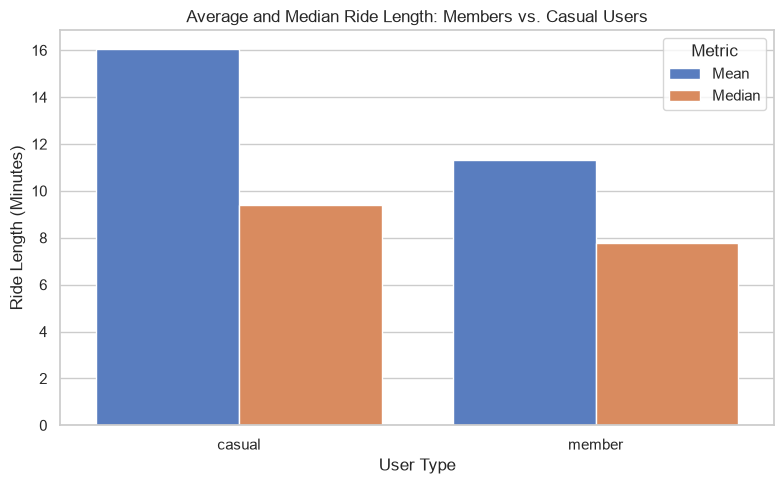

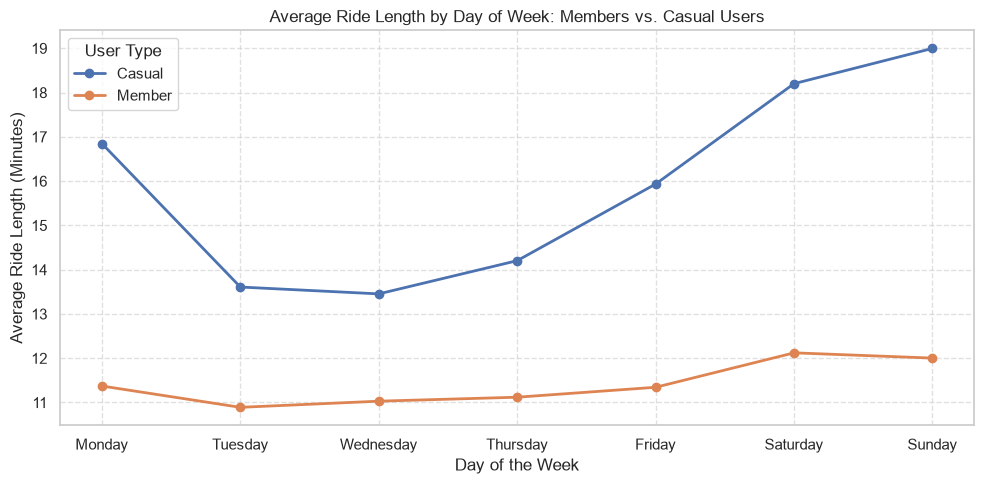

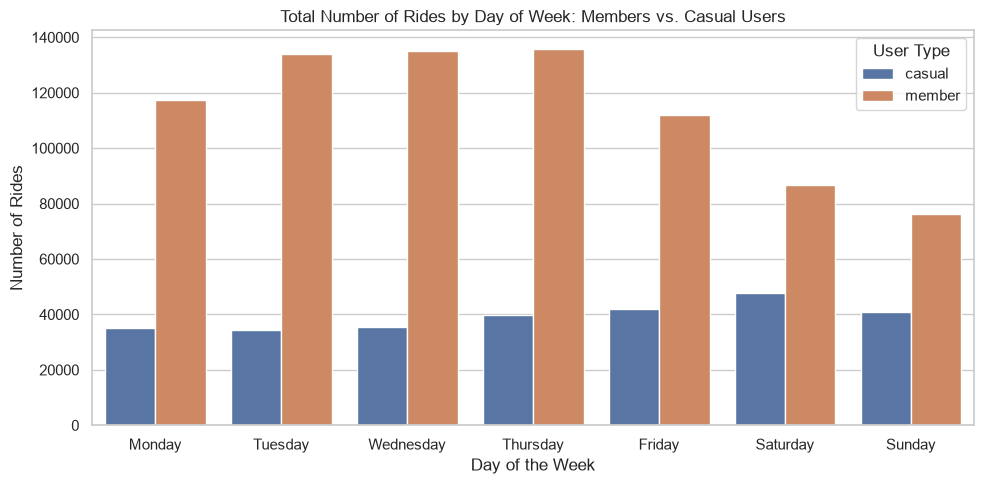

In [12]:
import matplotlib.pyplot as plt 
import seaborn as sns

# Load cleaned dataset for plotting if not already loaded
if 'df_clean' not in locals():
    df_clean = pd.read_csv("cyclistic_2026_q1_clean.csv")
    df_clean['started_at'] = pd.to_datetime(df_clean['started_at'])
    df_clean['ended_at'] = pd.to_datetime(df_clean['ended_at'])

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Chart 1: Average/Median Ride Length Comparison
summary_stats = df_clean.groupby("member_casual")["ride_length"].agg(
    Mean="mean",
    Median="median"
).reset_index()

summary_melted = pd.melt(summary_stats, id_vars="member_casual", value_vars=["Mean", "Median"], 
                         var_name="Metric", value_name="Minutes")

plt.figure(figsize=(8, 5))
sns.barplot(data=summary_melted, x="member_casual", y="Minutes", hue="Metric", palette="muted")
plt.title("Average and Median Ride Length: Members vs. Casual Users")
plt.xlabel("User Type")
plt.ylabel("Ride Length (Minutes)")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# Chart 2: Weekly Ride Duration Profile
pivot_avg = df_clean.pivot_table(
    values="ride_length",
    index="member_casual",
    columns="day_of_week",
    aggfunc="mean"
).reindex(columns=day_order).T

plt.figure(figsize=(10, 5))
for user_type in pivot_avg.columns:
    plt.plot(pivot_avg.index, pivot_avg[user_type], marker='o', label=user_type.capitalize(), linewidth=2)
plt.title("Average Ride Length by Day of Week: Members vs. Casual Users")
plt.xlabel("Day of the Week")
plt.ylabel("Average Ride Length (Minutes)")
plt.legend(title="User Type")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Chart 3: Weekly Ride Counts
pivot_count = df_clean.pivot_table(
    values="ride_id",
    index="member_casual",
    columns="day_of_week",
    aggfunc="count"
).reindex(columns=day_order).reset_index()

pivot_count_melted = pd.melt(pivot_count, id_vars="member_casual", value_vars=day_order,
                              var_name="day_of_week", value_name="ride_count")

plt.figure(figsize=(10, 5))
sns.barplot(data=pivot_count_melted, x="day_of_week", y="ride_count", hue="member_casual", palette="deep")
plt.title("Total Number of Rides by Day of Week: Members vs. Casual Users")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Rides")
plt.legend(title="User Type")
plt.tight_layout()
plt.show()


## Step 10: Advanced Analytical Insights
In this section, we expand our analysis beyond basic descriptive statistics to identify key behavioral differences that could help guide marketing strategies. Specifically, we explore:
1. **Bike Preferences:** Do members and casual riders prefer different bike types (classic vs. electric)?
2. **Hourly Usage (Rush Hour Patterns):** When do members and casual riders start their trips throughout the day?
3. **Round Trip Behavior:** Do casual riders use the bikes for recreational loops more often than members?
4. **Ride Distance & Speed:** Who rides faster, and does the distance covered differ?
5. **Top Route Profiles:** What are the most popular routes for each user group?

### Insight 1: Bike Type Preferences
We analyze whether user types have different preferences for electric vs. classic bikes.

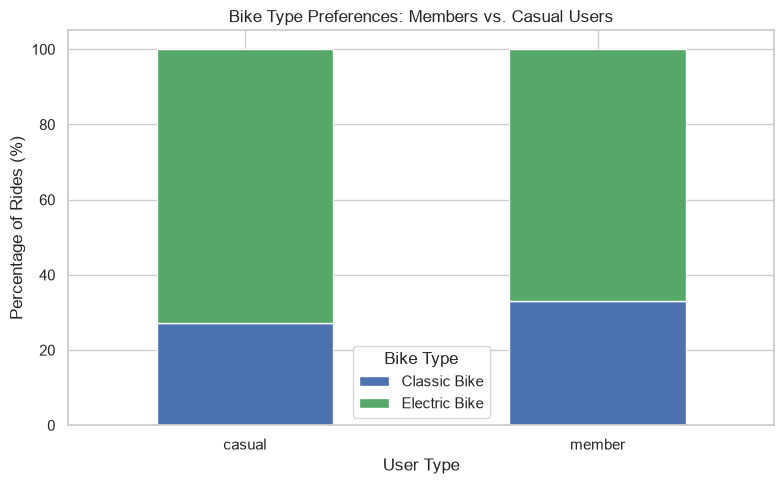

Bike Type Counts:
rideable_type  classic_bike  electric_bike
member_casual                             
casual                74632         200826
member               263561         533611

Bike Type Percentages:
rideable_type  classic_bike  electric_bike
member_casual                             
casual                27.09          72.91
member                33.06          66.94


In [13]:
# Group by user type and rideable type to count rides
bike_prefs = df_clean.groupby(['member_casual', 'rideable_type']).size().unstack(fill_value=0)
# Calculate proportion
bike_prefs_pct = bike_prefs.div(bike_prefs.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
plt.figure(figsize=(8, 5))
bike_prefs_pct.plot(kind='bar', stacked=True, color=['#4c72b0', '#55a868'], ax=plt.gca())
plt.title("Bike Type Preferences: Members vs. Casual Users")
plt.xlabel("User Type")
plt.ylabel("Percentage of Rides (%)")
plt.xticks(rotation=0)
plt.legend(title="Bike Type", labels=["Classic Bike", "Electric Bike"])
plt.tight_layout()
plt.show()

print("Bike Type Counts:")
print(bike_prefs)
print("\nBike Type Percentages:")
print(bike_prefs_pct.round(2))


### Insight 2: Hourly Usage Patterns (Rush Hour vs. Leisure Peak)
We extract the hour of the day from `started_at` to plot ride counts hour-by-hour (0 to 23). This helps distinguish daily commuter peaks from leisure peaks.

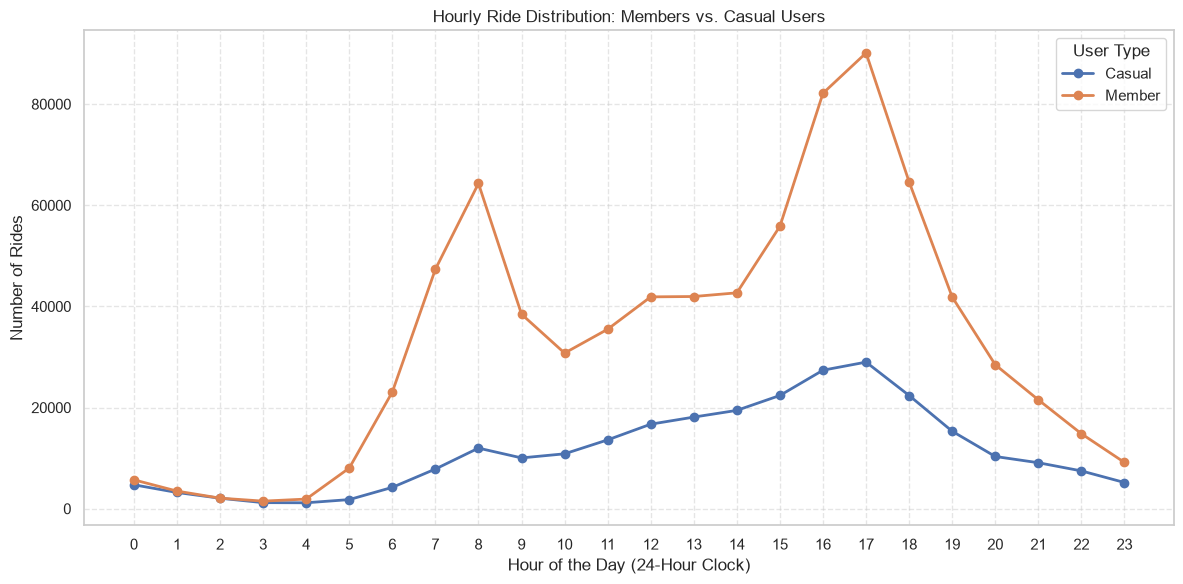

In [15]:
df_clean['started_at'] = pd.to_datetime(df_clean['started_at'])
df_clean['hour'] = df_clean['started_at'].dt.hour
hourly_rides = df_clean.groupby(['member_casual', 'hour']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
for user_type in hourly_rides.index:
    plt.plot(hourly_rides.columns, hourly_rides.loc[user_type], marker='o', label=user_type.capitalize(), linewidth=2)

plt.title("Hourly Ride Distribution: Members vs. Casual Users")
plt.xlabel("Hour of the Day (24-Hour Clock)")
plt.ylabel("Number of Rides")
plt.xticks(range(0, 24))
plt.legend(title="User Type")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Insight 3: Round Trip Behavior
A round trip occurs when a user starts and ends a ride at the same station. We exclude "On-Street (Dockless)" locations to focus on official stations.

C:\Users\KC\AppData\Local\Temp\ipykernel_12696\4290492467.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=round_trips_pct.reset_index(), x="member_casual", y=True, palette="rocket")


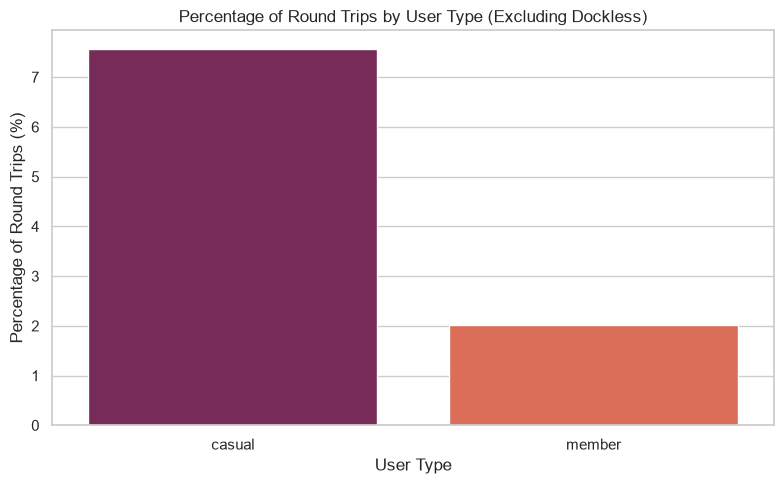

Round Trip Percentages:
is_round_trip  False  True 
member_casual              
casual         92.44   7.56
member         97.97   2.03


In [16]:
# Filter out dockless
df_non_dockless = df_clean[
    (df_clean['start_station_name'] != 'On-Street (Dockless)') &
    (df_clean['end_station_name'] != 'On-Street (Dockless)')
].copy()
df_non_dockless['is_round_trip'] = df_non_dockless['start_station_name'] == df_non_dockless['end_station_name']

round_trips_pct = df_non_dockless.groupby('member_casual')['is_round_trip'].value_counts(normalize=True).unstack() * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=round_trips_pct.reset_index(), x="member_casual", y=True, palette="rocket")
plt.title("Percentage of Round Trips by User Type (Excluding Dockless)")
plt.xlabel("User Type")
plt.ylabel("Percentage of Round Trips (%)")
plt.tight_layout()
plt.show()

print("Round Trip Percentages:")
print(round_trips_pct.round(2))


### Insight 4: Ride Distance & Speed (Haversine Distance)
We calculate the straight-line displacement (Haversine distance) between the start and end coordinates, and use it to estimate the average riding speed (km/h).

C:\Users\KC\AppData\Local\Temp\ipykernel_12696\72985303.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_stats, x="member_casual", y="distance_km", ax=axes[0], palette="Blues_d")
C:\Users\KC\AppData\Local\Temp\ipykernel_12696\72985303.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=speed_stats, x="member_casual", y="speed_kmh", ax=axes[1], palette="Oranges_d")


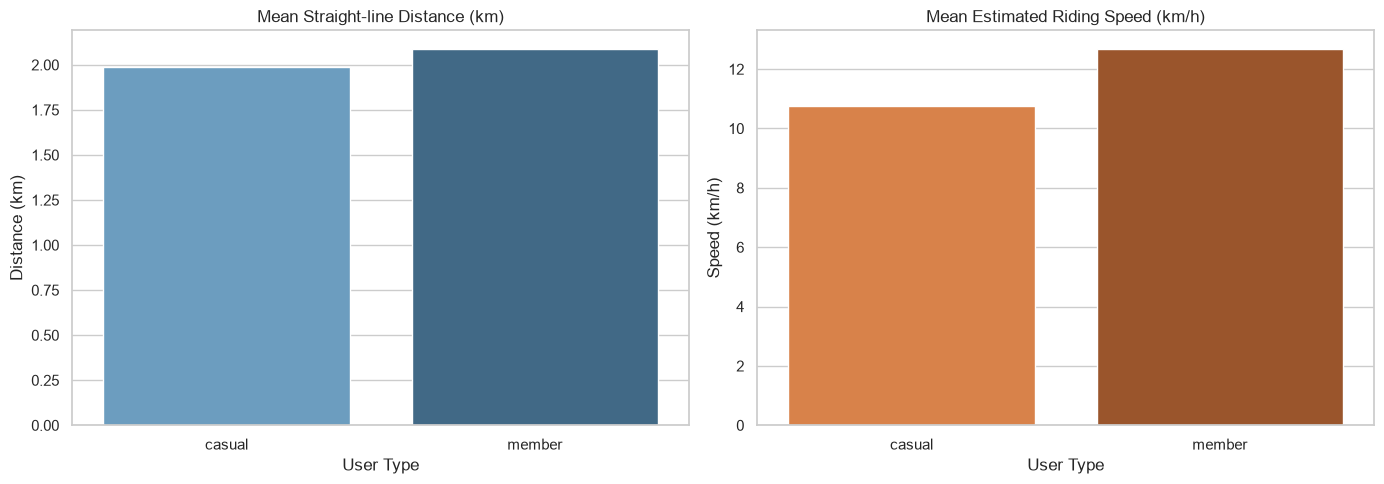

Distance and Speed Summaries:
              distance_km        speed_kmh       
                     mean median      mean median
member_casual                                    
casual               1.99   1.48     10.76  11.04
member               2.09   1.50     12.67  12.60


In [17]:
# Haversine distance calculator
def haversine_dist(lat1, lon1, lat2, lon2):
    R = 6371.0 # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

import numpy as np
df_clean['distance_km'] = haversine_dist(
    df_clean['start_lat'], df_clean['start_lng'], 
    df_clean['end_lat'], df_clean['end_lng']
)
# Calculate speed: distance_km / duration_hours
df_clean['speed_kmh'] = df_clean['distance_km'] / (df_clean['ride_length'] / 60)

# Plot comparisons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance comparison
dist_stats = df_clean.groupby('member_casual')['distance_km'].mean().reset_index()
sns.barplot(data=dist_stats, x="member_casual", y="distance_km", ax=axes[0], palette="Blues_d")
axes[0].set_title("Mean Straight-line Distance (km)")
axes[0].set_xlabel("User Type")
axes[0].set_ylabel("Distance (km)")

# Speed comparison
speed_stats = df_clean.groupby('member_casual')['speed_kmh'].mean().reset_index()
sns.barplot(data=speed_stats, x="member_casual", y="speed_kmh", ax=axes[1], palette="Oranges_d")
axes[1].set_title("Mean Estimated Riding Speed (km/h)")
axes[1].set_xlabel("User Type")
axes[1].set_ylabel("Speed (km/h)")

plt.tight_layout()
plt.show()

print("Distance and Speed Summaries:")
print(df_clean.groupby('member_casual')[['distance_km', 'speed_kmh']].agg(['mean', 'median']).round(2))


### Insight 5: Top 5 Routes Profile
We analyze the most popular routes (start-to-end station pairs) for members and casual riders, excluding "On-Street (Dockless)" locations.

C:\Users\KC\AppData\Local\Temp\ipykernel_12696\2971811688.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_routes.values, y=top_routes.index, ax=axes[i], palette="viridis")
C:\Users\KC\AppData\Local\Temp\ipykernel_12696\2971811688.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_routes.values, y=top_routes.index, ax=axes[i], palette="viridis")


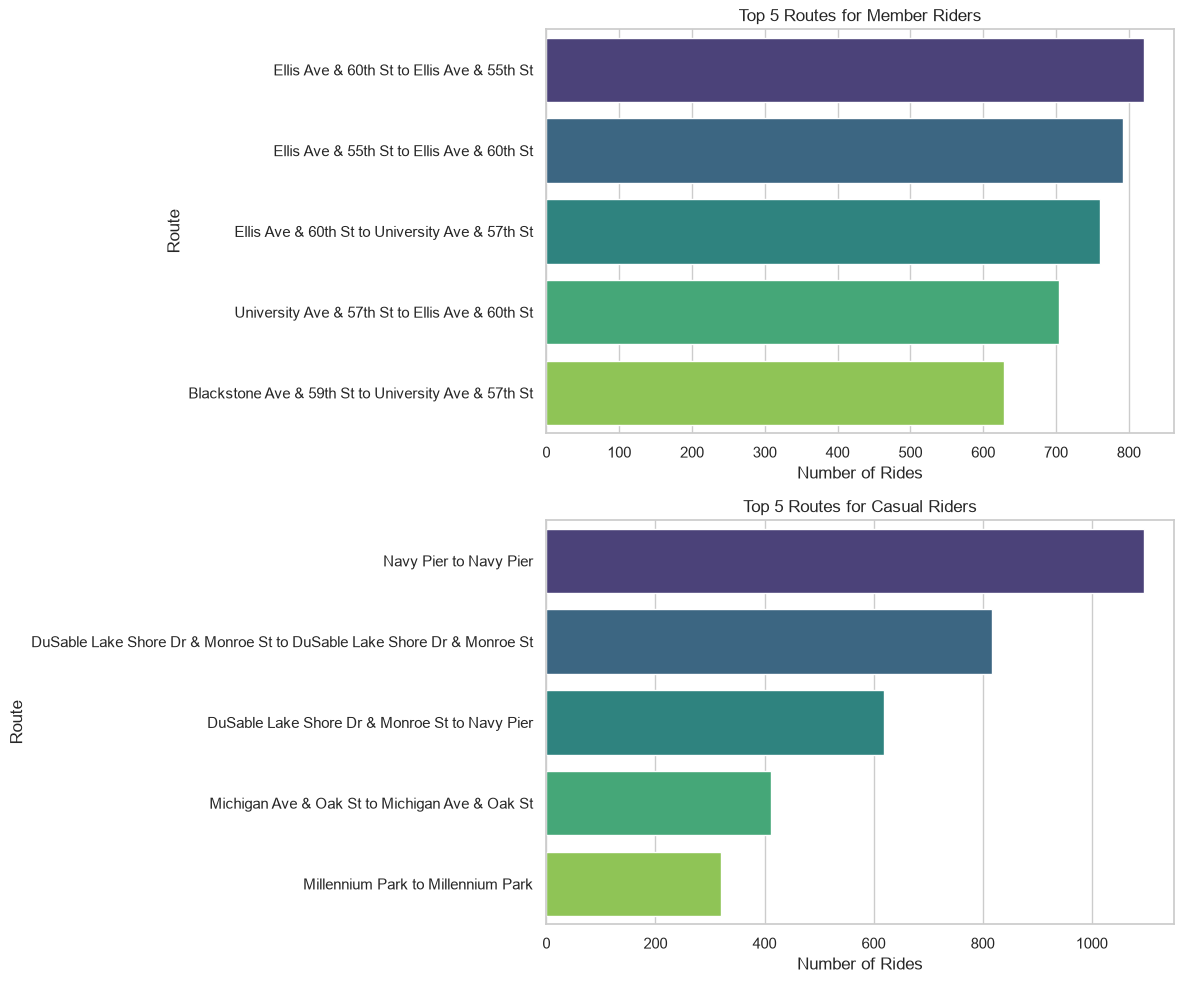

In [18]:
# Filter out dockless
df_valid_stations = df_clean[
    (df_clean['start_station_name'] != 'On-Street (Dockless)') &
    (df_clean['end_station_name'] != 'On-Street (Dockless)')
].copy()
df_valid_stations['route'] = df_valid_stations['start_station_name'] + " to " + df_valid_stations['end_station_name']

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for i, user_type in enumerate(['member', 'casual']):
    top_routes = df_valid_stations[df_valid_stations['member_casual'] == user_type]['route'].value_counts().head(5)
    sns.barplot(x=top_routes.values, y=top_routes.index, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Top 5 Routes for {user_type.capitalize()} Riders")
    axes[i].set_xlabel("Number of Rides")
    axes[i].set_ylabel("Route")

plt.tight_layout()
plt.show()
